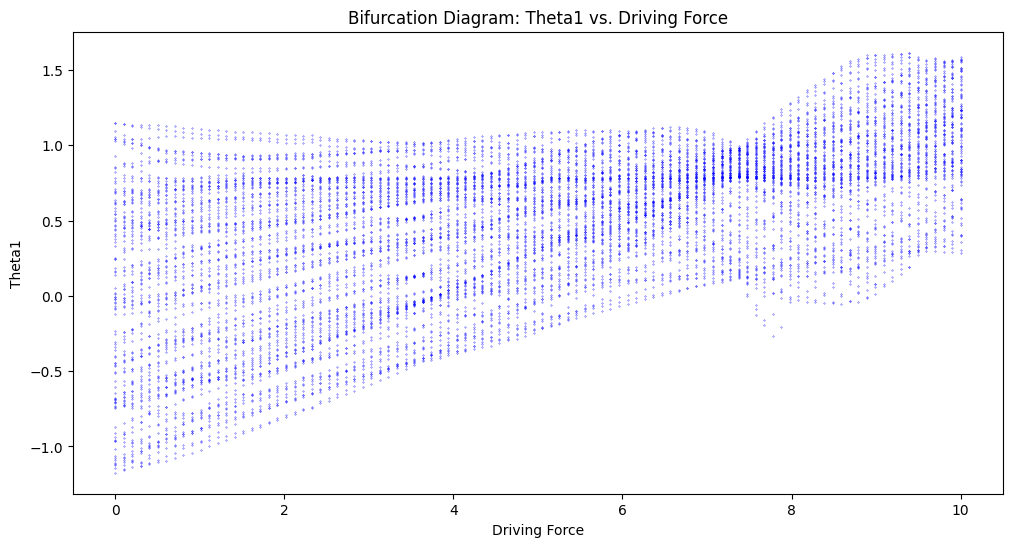

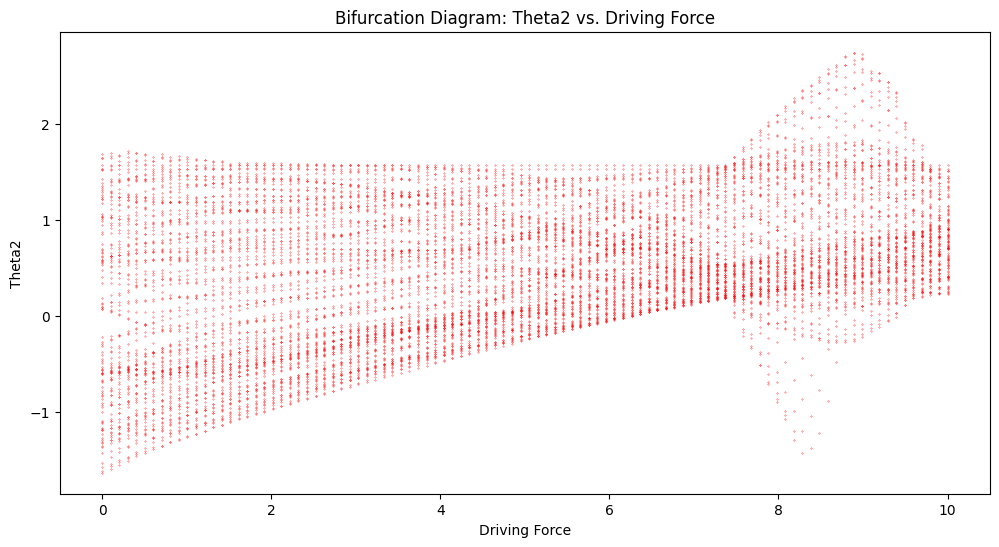

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the double pendulum system
def double_pendulum(t, y, L1, L2, m1, m2, driving_force):
    theta1, z1, theta2, z2 = y
    c, s = np.cos(theta1-theta2), np.sin(theta1-theta2)
    
    theta1dot = z1
    z1dot = (m2*9.81*np.sin(theta2)*c - m2*s*(L1*z1**2*c + L2*z2**2) - (m1+m2)*9.81*np.sin(theta1) + driving_force) / L1 / (m1 + m2*s**2)
    theta2dot = z2
    z2dot = ((m1+m2)*(L1*z1**2*s - 9.81*np.sin(theta2) + 9.81*np.sin(theta1)*c) + m2*L2*z2**2*s*c) / L2 / (m1 + m2*s**2)
    
    return [theta1dot, z1dot, theta2dot, z2dot]

# Parameters
L1, L2 = 1.0, 1.0
m1, m2 = 1.0, 1.0
t_span = [0, 10]
t_eval = np.linspace(t_span[0], t_span[1], 100)

# Initial conditions
y0 = [np.pi/4, 0, np.pi/2, 0]

# Driving force range
driving_forces = np.linspace(0, 10, 100)

# Bifurcation plot data
theta1_values = []
theta2_values = []

for driving_force in driving_forces:
    sol = solve_ivp(double_pendulum, t_span, y0, args=(L1, L2, m1, m2, driving_force), t_eval=t_eval)
    theta1_values.append(sol.y[0][-100:])  # Take the last 100 points to avoid transients
    theta2_values.append(sol.y[2][-100:])  # Take the last 100 points to avoid transients

# Plotting the bifurcation diagram for theta1
plt.figure(figsize=(12, 6))
for i, driving_force in enumerate(driving_forces):
    plt.plot([driving_force]*len(theta1_values[i]), theta1_values[i], 'b.', markersize=0.5)

plt.xlabel('Driving Force')
plt.ylabel('Theta1')
plt.title('Bifurcation Diagram: Theta1 vs. Driving Force')
plt.show()

# Plotting the bifurcation diagram for theta2
plt.figure(figsize=(12, 6))
for i, driving_force in enumerate(driving_forces):
    plt.plot([driving_force]*len(theta2_values[i]), theta2_values[i], 'r.', markersize=0.5)

plt.xlabel('Driving Force')
plt.ylabel('Theta2')
plt.title('Bifurcation Diagram: Theta2 vs. Driving Force')
plt.show()

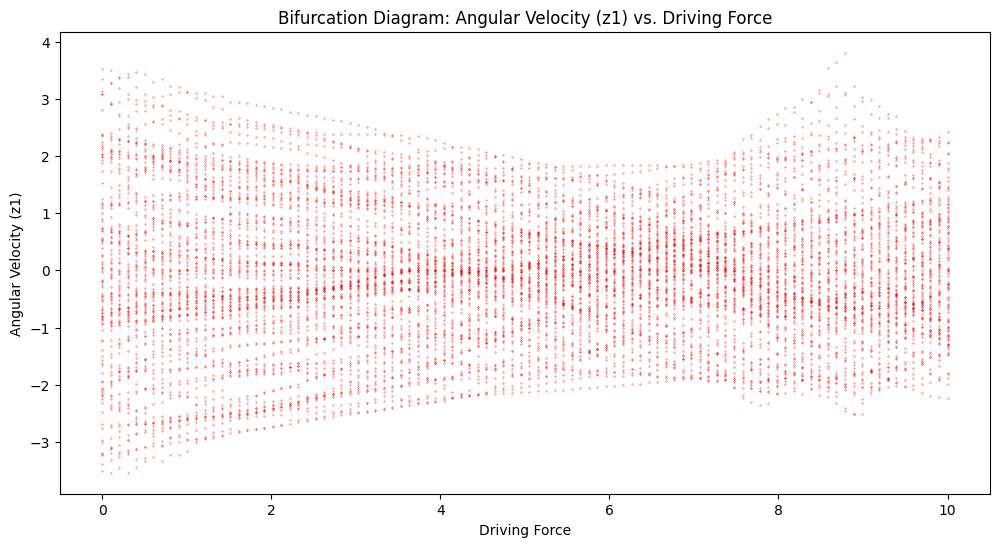

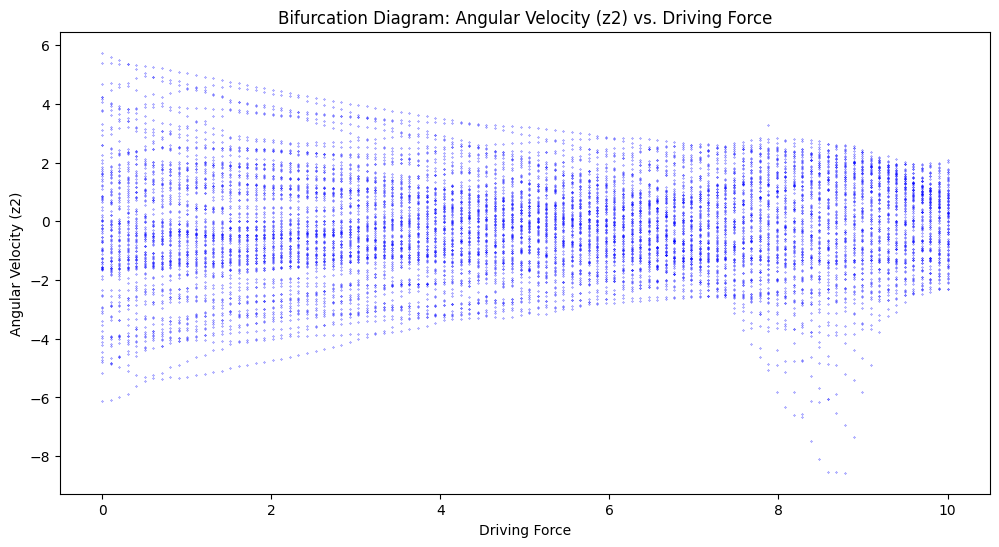

In [10]:

# Bifurcation plot data for angular velocities
z1_values = []
z2_values = []

for driving_force in driving_forces:
    sol = solve_ivp(double_pendulum, t_span, y0, args=(L1, L2, m1, m2, driving_force), t_eval=t_eval)
    z1_values.append(sol.y[1][-100:])  # Take the last 100 points to avoid transients
    z2_values.append(sol.y[3][-100:])  # Take the last 100 points to avoid transients

# Plotting the bifurcation diagram for angular velocity z1
plt.figure(figsize=(12, 6))
for i, driving_force in enumerate(driving_forces):
    plt.plot([driving_force]*len(z1_values[i]), z1_values[i], 'r.', markersize=0.5)

plt.xlabel('Driving Force')
plt.ylabel('Angular Velocity (z1)')
plt.title('Bifurcation Diagram: Angular Velocity (z1) vs. Driving Force')
plt.show()

# Plotting the bifurcation diagram for angular velocity z2
plt.figure(figsize=(12, 6))
for i, driving_force in enumerate(driving_forces):
    plt.plot([driving_force]*len(z2_values[i]), z2_values[i], 'b.', markersize=0.5)

plt.xlabel('Driving Force')
plt.ylabel('Angular Velocity (z2)')
plt.title('Bifurcation Diagram: Angular Velocity (z2) vs. Driving Force')
plt.show()

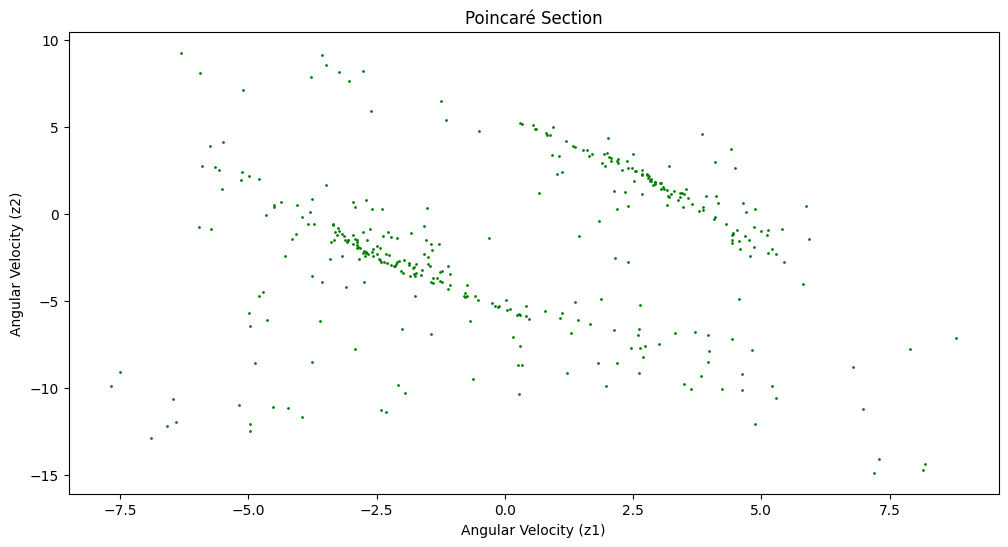

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the double pendulum system
def double_pendulum(t, y, L1, L2, m1, m2, driving_force):
    theta1, z1, theta2, z2 = y
    c, s = np.cos(theta1-theta2), np.sin(theta1-theta2)
    
    theta1dot = z1
    z1dot = (m2*9.81*np.sin(theta2)*c - m2*s*(L1*z1**2*c + L2*z2**2) - (m1+m2)*9.81*np.sin(theta1) + driving_force) / L1 / (m1 + m2*s**2)
    theta2dot = z2
    z2dot = ((m1+m2)*(L1*z1**2*s - 9.81*np.sin(theta2) + 9.81*np.sin(theta1)*c) + m2*L2*z2**2*s*c) / L2 / (m1 + m2*s**2)
    
    return [theta1dot, z1dot, theta2dot, z2dot]

# Parameters
L1, L2 = 1.0, 1.0
m1, m2 = 1.0, 1.0
t_span = [0, 1000]  # Increase the time span
t_eval = np.linspace(t_span[0], t_span[1], 10000)

# Initial conditions
y0 = [np.pi/4, 0, np.pi/2, 0]
driving_force = 0  # Example driving force

# Solve the ODE
sol = solve_ivp(double_pendulum, t_span, y0, args=(L1, L2, m1, m2, driving_force), t_eval=t_eval)

# Define the Poincaré section function
def poincare_section(sol, section_angle):
    indices = np.where(np.abs(np.diff(np.sign(sol.y[0] - section_angle))) > 0)[0]
    return sol.y[1][indices], sol.y[3][indices]

# Calculate the Poincaré section
section_angle = 0  # Example section angle
z1_section, z2_section = poincare_section(sol, section_angle)

# Plotting the Poincaré section
plt.figure(figsize=(12, 6))
plt.plot(z1_section, z2_section, 'g.', markersize=2)
plt.xlabel('Angular Velocity (z1)')
plt.ylabel('Angular Velocity (z2)')
plt.title('Poincaré Section')
plt.show()